#  PROJECT: SOCIAL MEDIA BOT DETECTION
## Notebook: 02_Twitter_Full_Analysis.ipynb

**Course:** CCS4310 Deep Learning Project  
**Component:** Twitter / X Bot Detection Pipeline (End-to-End Multimodal Analysis)  
**Dataset:** Gilani-2017 Benchmark Dataset (TSV Labels & Tweet/Profile JSON)  
**Target:** Binary Classification (0 = Human / Authentic Account, 1 = Bot / Automated Account)

---
### Comprehensive Pipeline Roadmap:
1. **Google Drive Integration & Centralized Path Setup**
2. **Environment Configuration & Reproducibility Seeds**
3. **Dataset Inspection & Loading (TSV Labels + Tweet/Profile JSON)**
4. **Label Processing & Disambiguation (Transparent Conflict Resolution)**
5. **Profile Data Extraction & Relational Merge**
6. **Data Quality Audit (Missing Values, Duplicates, Distribution, Summary Stats)**
7. **Profile Feature Engineering & Cleaned Dataset Export**
8. **Exploratory Data Analysis (EDA - Individual Visualizations):**
   - Target Distribution Bar Chart
   - Numerical Feature Histograms with Kernel Density Estimation (KDE)
   - Feature Boxplots Segmented by Class
   - Binary Feature Proportions
   - Pearson Correlation Heatmap
9. **Zero-Leakage Preprocessing & Stratified Train/Test Split**
10. **Profile Machine Learning Models:**
    - Model 1: Logistic Regression
    - Model 2: Random Forest & Gini Feature Importance
    - Model 3: XGBoost Classifier & Gain Feature Importance
    - Profile ML Model Comparison Table
11. **Natural Language Processing (NLP) Modeling:**
    - Text Feature Construction (`description`, `name`, `screen_name`)
    - Zero-Leakage TF-IDF Vectorization
    - TF-IDF + Logistic Regression Classifier
    - Discriminative Word Importance Graph & Classification Report
12. **Graph Neural Network (GCN) Modeling:**
    - Explicit Methodological Statement on Edge Topology
    - KNN-Based Profile Graph Construction
    - Pure PyTorch GCN Architecture & Training with Loss Tracking
    - GNN Test Set Evaluation
13. **Master Multimodal Benchmark & Complete Model Comparison**
    - Multi-Category Leaderboard (Profile ML, NLP, GNN)
    - Accuracy Comparison Bar Chart
    - F1-Score Comparison Bar Chart
14. **Receiver Operating Characteristic (ROC) & AUC Analysis**
15. **Executive Summary & Best Twitter Model Determination**
16. **System Artifact Audit & Verification Check**

---
## 1. Google Drive Connection & Centralized Directory Architecture
Mount Google Drive and create standardized project directories automatically.

In [1]:
# ==============================================================================
# GOOGLE DRIVE CONNECTION & PROJECT DIRECTORY ARCHITECTURE
# ==============================================================================
import os
import sys
import shutil

# Connect Google Drive when executing inside Google Colab
try:
    from google.colab import drive
    drive.mount('/content/drive')
    print("[SUCCESS] Google Drive mounted successfully.")
except ImportError:
    print("[INFO] Non-Colab environment detected. Using local directory paths.")

# Define centralized BASE_PATH and subdirectories
BASE_PATH = "/content/drive/MyDrive/Bot_Detection_Project"

DATA_PATH   = BASE_PATH + "/data/twitter"
RESULT_PATH = BASE_PATH + "/results/twitter"
GRAPH_PATH  = BASE_PATH + "/graphs/twitter"
MODEL_PATH  = BASE_PATH + "/models/twitter"

# Create directories automatically
for path in [DATA_PATH, RESULT_PATH, GRAPH_PATH, MODEL_PATH]:
    os.makedirs(path, exist_ok=True)

print("\nTwitter Project Directory Architecture Initialized:")
print(f"  BASE_PATH   : {BASE_PATH}")
print(f"  DATA_PATH   : {DATA_PATH}")
print(f"  RESULT_PATH : {RESULT_PATH}")
print(f"  GRAPH_PATH  : {GRAPH_PATH}")
print(f"  MODEL_PATH  : {MODEL_PATH}")

Mounted at /content/drive
[SUCCESS] Google Drive mounted successfully.

Twitter Project Directory Architecture Initialized:
  BASE_PATH   : /content/drive/MyDrive/Bot_Detection_Project
  DATA_PATH   : /content/drive/MyDrive/Bot_Detection_Project/data/twitter
  RESULT_PATH : /content/drive/MyDrive/Bot_Detection_Project/results/twitter
  GRAPH_PATH  : /content/drive/MyDrive/Bot_Detection_Project/graphs/twitter
  MODEL_PATH  : /content/drive/MyDrive/Bot_Detection_Project/models/twitter


---
## 2. Library Imports & Reproducibility Configuration
Import required analytical, text-processing, machine learning, and deep graph learning libraries. Set global seeds for deterministic repeatability.

In [2]:
# ==============================================================================
# IMPORT REQUIRED LIBRARIES & SET REPRODUCIBILITY SEEDS
# ==============================================================================
import os
import re
import json
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# Scikit-Learn: Preprocessing, Metrics, Models & Text
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import kneighbors_graph
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve, roc_auc_score
)

# XGBoost
import xgboost as xgb

# PyTorch for Graph Convolutional Network (GCN)
import torch
import torch.nn as nn
import torch.nn.functional as F

# Visualization aesthetics
warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['figure.dpi'] = 120

# Global Seed Initialization
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)

print("Environment configured with reproducibility seed:", SEED)
print("PyTorch Version :", torch.__version__)
print("XGBoost Version :", xgb.__version__)

Environment configured with reproducibility seed: 42
PyTorch Version : 2.11.0+cpu
XGBoost Version : 3.4.1


---
## 3. Dataset Inspection & Loading (TSV Labels + Tweet/Profile JSON)
Inspect `DATA_PATH`, locate `gilani-2017.tsv` and `gilani-2017_tweets.json`, inspect their structures, and handle fallbacks.

In [3]:
# ==============================================================================
# FIND AND LOAD TWITTER DATASETS
# ==============================================================================
print(f"Scanning DATA_PATH: {DATA_PATH}")
found_files = sorted(os.listdir(DATA_PATH)) if os.path.exists(DATA_PATH) else []
print(f"Files found ({len(found_files)}):")
for f in found_files:
    f_path = os.path.join(DATA_PATH, f)
    if os.path.isfile(f_path):
        print(f"  - {f} ({os.path.getsize(f_path):,} bytes)")

# Auto-copy fallback if running outside Drive or before file sync
if not any(f.endswith('.tsv') or f.endswith('.json') for f in found_files):
    local_candidates = ["data/twitter", "../data/twitter", "./data/twitter"]
    for cand in local_candidates:
        if os.path.exists(cand):
            for item in os.listdir(cand):
                src_item = os.path.join(cand, item)
                if os.path.isfile(src_item):
                    shutil.copy(src_item, os.path.join(DATA_PATH, item))
            print(f"[INFO] Auto-copied dataset files from '{cand}' to '{DATA_PATH}'")
            found_files = sorted(os.listdir(DATA_PATH))
            break

# 1. Load TSV Labels (gilani-2017.tsv)
tsv_path = os.path.join(DATA_PATH, "gilani-2017.tsv")
if os.path.exists(tsv_path):
    tsv_df = pd.read_csv(tsv_path, sep='\t', header=None, names=['user_id', 'raw_label'])
    print(f"\nLoaded TSV Labels: {tsv_df.shape[0]:,} rows, {tsv_df.shape[1]} columns")
    print(f"TSV Column Names : {list(tsv_df.columns)}")
    print("First 5 rows of TSV:")
    display(tsv_df.head())
    print("\nTSV Data Types:")
    print(tsv_df.dtypes)
else:
    raise FileNotFoundError(f"Missing '{tsv_path}'. Please place gilani-2017.tsv in DATA_PATH.")

# 2. Load Profile JSON (gilani-2017_tweets.json)
json_path = os.path.join(DATA_PATH, "gilani-2017_tweets.json")
if os.path.exists(json_path):
    print(f"\nLoading JSON dataset from: {json_path} ...")
    with open(json_path, 'r', encoding='utf-8') as f:
        json_data = json.load(f)
    print(f"Loaded JSON: {len(json_data):,} entries parsed.")
else:
    raise FileNotFoundError(f"Missing '{json_path}'. Please place gilani-2017_tweets.json in DATA_PATH.")

Scanning DATA_PATH: /content/drive/MyDrive/Bot_Detection_Project/data/twitter
Files found (2):
  - gilani-2017.tsv (41,126 bytes)
  - gilani-2017_tweets.json (4,590,702 bytes)

Loaded TSV Labels: 2,652 rows, 2 columns
TSV Column Names : ['user_id', 'raw_label']
First 5 rows of TSV:


,user_id,raw_label
0,461277906,bot
1,808280162,bot
2,1575510320,bot
3,2449235599,bot
4,1113769100,bot



TSV Data Types:
user_id       int64
raw_label    object
dtype: object

Loading JSON dataset from: /content/drive/MyDrive/Bot_Detection_Project/data/twitter/gilani-2017_tweets.json ...
Loaded JSON: 2,494 entries parsed.


---
## 4. Label Processing & Transparent Conflict Resolution
Analyze ground-truth labels from TSV, map binary classes (bot = 1, human = 0), and resolve conflicting duplicate annotations.

In [4]:
# ==============================================================================
# LABEL PROCESSING & CONFLICT RESOLUTION
# ==============================================================================
print("=== Raw Label Distribution in TSV ===")
print(tsv_df['raw_label'].value_counts())

# Inspect duplicates in TSV
tsv_total_rows = len(tsv_df)
tsv_unique_ids = tsv_df['user_id'].nunique()
tsv_duplicates = tsv_df['user_id'].duplicated().sum()

print(f"\nTSV Total Rows       : {tsv_total_rows:,}")
print(f"TSV Unique User IDs  : {tsv_unique_ids:,}")
print(f"TSV Duplicate IDs    : {tsv_duplicates:,}")

# Identify conflicting annotations where the same user ID is labeled as both bot and human
dup_rows = tsv_df[tsv_df['user_id'].duplicated(keep=False)].sort_values('user_id')
conflict_group = dup_rows.groupby('user_id')['raw_label'].nunique()
conflicting_ids = conflict_group[conflict_group > 1].index.tolist()

print(f"\nUser IDs with CONFLICTING labels (both 'bot' and 'human'): {len(conflicting_ids)}")
if conflicting_ids:
    print("Sample conflicting rows:")
    display(tsv_df[tsv_df['user_id'].isin(conflicting_ids[:5])].sort_values('user_id'))

# Transparent conflict resolution: Remove ambiguous user IDs to preserve label integrity
print("\n[METHODOLOGY] Dropping the 19 user IDs with conflicting annotations to maintain strict ground-truth validity.")
tsv_clean = tsv_df[~tsv_df['user_id'].isin(conflicting_ids)].copy()

# Drop any remaining exact duplicates if present
tsv_clean = tsv_clean.drop_duplicates(subset=['user_id']).reset_index(drop=True)

# Standardize binary target: bot = 1, human = 0
label_mapping = {'human': 0, 'bot': 1}
tsv_clean['target'] = tsv_clean['raw_label'].str.strip().str.lower().map(label_mapping)

print(f"\nTSV Cleaned Rows     : {len(tsv_clean):,}")
print("Final Binary Class Mapping: {'human': 0, 'bot': 1}")
print("\nCleaned Target Class Counts:")
print(tsv_clean['target'].value_counts())

# Save conflict audit report
conflict_report_df = pd.DataFrame({
    'Metric': ['Total TSV Entries', 'Unique User IDs', 'Duplicate Entries', 'Conflicting User IDs Dropped', 'Cleaned Unique Annotations'],
    'Count': [tsv_total_rows, tsv_unique_ids, tsv_duplicates, len(conflicting_ids), len(tsv_clean)]
})
conflict_csv_path = os.path.join(RESULT_PATH, "merge_summary.csv")
conflict_report_df.to_csv(conflict_csv_path, index=False)
print(f"\n[SAVED] Merge & conflict summary: {conflict_csv_path}")

=== Raw Label Distribution in TSV ===
raw_label
human    1522
bot      1130
Name: count, dtype: int64

TSV Total Rows       : 2,652
TSV Unique User IDs  : 2,633
TSV Duplicate IDs    : 19

User IDs with CONFLICTING labels (both 'bot' and 'human'): 19
Sample conflicting rows:


,user_id,raw_label
1103,16186995,bot
2607,16186995,human
2597,19129949,human
1096,19129949,bot
2443,19564719,human
1004,19564719,bot
2424,23042027,human
994,23042027,bot
1097,39985029,bot
2600,39985029,human



[METHODOLOGY] Dropping the 19 user IDs with conflicting annotations to maintain strict ground-truth validity.

TSV Cleaned Rows     : 2,614
Final Binary Class Mapping: {'human': 0, 'bot': 1}

Cleaned Target Class Counts:
target
0    1503
1    1111
Name: count, dtype: int64

[SAVED] Merge & conflict summary: /content/drive/MyDrive/Bot_Detection_Project/results/twitter/merge_summary.csv


---
## 5. Profile Data Extraction & Relational Merge
Extract user profile objects from the parsed JSON, align user IDs across both datasets, and perform a strict inner merge.

In [5]:
# ==============================================================================
# PROFILE EXTRACTION FROM JSON & MERGING WITH GROUND TRUTH
# ==============================================================================
# Extract user profile dictionary from each item
profile_records = []
for item in json_data:
    if isinstance(item, dict):
        if 'user' in item and isinstance(item['user'], dict):
            profile_records.append(item['user'])
        elif 'id' in item and 'followers_count' in item:
            profile_records.append(item)

df_json_users = pd.DataFrame(profile_records)
print(f"Extracted User Profiles from JSON: {df_json_users.shape[0]:,} records, {df_json_users.shape[1]} fields")

# Inspect available fields
relevant_fields = [
    'id', 'name', 'screen_name', 'location', 'description',
    'followers_count', 'friends_count', 'listed_count', 'favourites_count',
    'verified', 'statuses_count', 'protected', 'default_profile', 'default_profile_image'
]
available_fields = [c for c in relevant_fields if c in df_json_users.columns]
print(f"Extracted {len(available_fields)} Available Profile Fields:\n{available_fields}")

# Deduplicate profiles by user ID
df_json_users = df_json_users[available_fields].drop_duplicates(subset=['id']).reset_index(drop=True)
print(f"Unique Profiles in JSON: {df_json_users.shape[0]:,}")

# Ensure compatible key types for relational merge
tsv_clean['user_id'] = tsv_clean['user_id'].astype(np.int64)
df_json_users['id'] = df_json_users['id'].astype(np.int64)

# Execute Inner Merge
merged_df = pd.merge(df_json_users, tsv_clean[['user_id', 'target', 'raw_label']],
                     left_on='id', right_on='user_id', how='inner')

print(f"\nFinal Merged Dataset Shape: {merged_df.shape[0]:,} rows, {merged_df.shape[1]} columns")
print("Target Class Distribution:")
print(merged_df['target'].value_counts())
display(merged_df.head(3))

Extracted User Profiles from JSON: 2,494 records, 42 fields
Extracted 14 Available Profile Fields:
['id', 'name', 'screen_name', 'location', 'description', 'followers_count', 'friends_count', 'listed_count', 'favourites_count', 'verified', 'statuses_count', 'protected', 'default_profile', 'default_profile_image']
Unique Profiles in JSON: 2,494

Final Merged Dataset Shape: 2,465 rows, 17 columns
Target Class Distribution:
target
0    1394
1    1071
Name: count, dtype: int64


,id,name,screen_name,location,description,followers_count,friends_count,listed_count,favourites_count,verified,statuses_count,protected,default_profile,default_profile_image,user_id,target,raw_label
0,613512037,Baseball Quotes,BaseballQuotes1,The Diamond,Quoting America's Pastime in 280 characters or...,121500,346,532,35894,False,21246,False,False,False,613512037,0,human
1,19263978,Cleveland Cavaliers,cavs,"The Q | Cleveland, OH",Official Twitter of the 2016 NBA Champion Clev...,3227215,1946,9039,16134,True,45791,False,False,False,19263978,0,human
2,1624329463,‏المهاجر 1M,muohajer_12,المملكة العربية السعودية,,864968,767106,1371,23,False,875763,False,True,False,1624329463,1,bot


---
## 6. Data Quality Audit
Inspect missing values, duplicate records, target balance, and initial summary statistics across merged profiles.

In [6]:
# ==============================================================================
# DATA QUALITY AUDIT: MISSING VALUES
# ==============================================================================
missing_counts = merged_df.isnull().sum()
missing_percentages = (missing_counts / len(merged_df)) * 100

missing_df = pd.DataFrame({
    'Feature': merged_df.columns,
    'Missing_Count': missing_counts.values,
    'Missing_Percentage': missing_percentages.round(2).values
})

print("=== Missing Values Summary across Profile Fields ===")
print(missing_df.to_string(index=False))

missing_csv_path = os.path.join(RESULT_PATH, "missing_values.csv")
missing_df.to_csv(missing_csv_path, index=False)
print(f"\n[SAVED] Missing values report: {missing_csv_path}")

=== Missing Values Summary across Profile Fields ===
              Feature  Missing_Count  Missing_Percentage
                   id              0                 0.0
                 name              0                 0.0
          screen_name              0                 0.0
             location              0                 0.0
          description              0                 0.0
      followers_count              0                 0.0
        friends_count              0                 0.0
         listed_count              0                 0.0
     favourites_count              0                 0.0
             verified              0                 0.0
       statuses_count              0                 0.0
            protected              0                 0.0
      default_profile              0                 0.0
default_profile_image              0                 0.0
              user_id              0                 0.0
               target              

In [7]:
# ==============================================================================
# DATA QUALITY AUDIT: DUPLICATE USERS
# ==============================================================================
exact_dup_rows = int(merged_df.duplicated().sum())
id_dup_count = int(merged_df['user_id'].duplicated().sum())

print(f"Exact Duplicate Rows: {exact_dup_rows}")
print(f"Duplicate User IDs  : {id_dup_count}")

dup_df = pd.DataFrame({
    'Metric': ['Total Merged Accounts', 'Unique User IDs', 'Duplicate Rows', 'Duplicate User IDs'],
    'Value': [len(merged_df), merged_df['user_id'].nunique(), exact_dup_rows, id_dup_count]
})
print("\n=== Duplicate Records Summary ===")
print(dup_df.to_string(index=False))

dup_csv_path = os.path.join(RESULT_PATH, "duplicate_summary.csv")
dup_df.to_csv(dup_csv_path, index=False)
print(f"\n[SAVED] Duplicate summary report: {dup_csv_path}")

Exact Duplicate Rows: 0
Duplicate User IDs  : 0

=== Duplicate Records Summary ===
               Metric  Value
Total Merged Accounts   2465
      Unique User IDs   2465
       Duplicate Rows      0
   Duplicate User IDs      0

[SAVED] Duplicate summary report: /content/drive/MyDrive/Bot_Detection_Project/results/twitter/duplicate_summary.csv


In [8]:
# ==============================================================================
# DATA QUALITY AUDIT: TARGET VALUES & CLASS DISTRIBUTION
# ==============================================================================

# Check target distribution
target_dist = (
    merged_df['target']
    .value_counts()
    .sort_index()
    .reset_index()
)

target_dist.columns = ['Class', 'Count']

# Calculate percentage
target_dist['Percentage'] = (
    target_dist['Count'] / len(merged_df) * 100
).round(2)

# Add class names
target_dist['Class_Name'] = target_dist['Class'].map({
    0: 'Human / Authentic (0)',
    1: 'Bot / Automated (1)'
})

print("=== Target Class Distribution Table ===")
print(target_dist.to_string(index=False))

# Verify the expected 60/40 distribution
print("\n=== Distribution Verification ===")

human_percentage = (
    (merged_df['target'] == 0).sum() / len(merged_df) * 100
)

bot_percentage = (
    (merged_df['target'] == 1).sum() / len(merged_df) * 100
)

print(f"Human / Authentic : {human_percentage:.2f}%")
print(f"Bot / Automated   : {bot_percentage:.2f}%")

# Save distribution table
target_csv_path = os.path.join(
    RESULT_PATH,
    "target_distribution.csv"
)

target_dist.to_csv(
    target_csv_path,
    index=False
)

print(
    f"\n[SAVED] Target distribution table: "
    f"{target_csv_path}"
)

=== Target Class Distribution Table ===
 Class  Count  Percentage            Class_Name
     0   1394       56.55 Human / Authentic (0)
     1   1071       43.45   Bot / Automated (1)

=== Distribution Verification ===
Human / Authentic : 56.55%
Bot / Automated   : 43.45%

[SAVED] Target distribution table: /content/drive/MyDrive/Bot_Detection_Project/results/twitter/target_distribution.csv


---
## 7. Feature Engineering & Dataset Standardization
Derive informative profile ratio metrics, metadata lengths, text indicators, and export both cleaned raw and feature datasets.

In [9]:
# ==============================================================================
# FEATURE ENGINEERING PIPELINE
# ==============================================================================
df_feat = merged_df.copy()

# 1. Profile interaction ratios
df_feat['followers_friends_ratio'] = (df_feat['followers_count'] + 1.0) / (df_feat['friends_count'] + 1.0)
df_feat['favourites_statuses_ratio'] = (df_feat['favourites_count'] + 1.0) / (df_feat['statuses_count'] + 1.0)
df_feat['statuses_followers_ratio'] = (df_feat['statuses_count'] + 1.0) / (df_feat['followers_count'] + 1.0)

# 2. Text-derived profile metadata features
df_feat['description'] = df_feat['description'].fillna('').astype(str)
df_feat['name'] = df_feat['name'].fillna('').astype(str)
df_feat['screen_name'] = df_feat['screen_name'].fillna('').astype(str)

df_feat['description_length'] = df_feat['description'].str.len()
df_feat['username_length'] = df_feat['screen_name'].str.len()
df_feat['username_digit_count'] = df_feat['screen_name'].apply(lambda s: sum(c.isdigit() for c in s))
df_feat['username_digit_ratio'] = df_feat['username_digit_count'] / df_feat['username_length'].replace(0, 1)

df_feat['fullname_length'] = df_feat['name'].str.len()
df_feat['fullname_word_count'] = df_feat['name'].apply(lambda s: len(s.split()))
df_feat['name_equals_username'] = (df_feat['name'].str.lower().str.strip() == df_feat['screen_name'].str.lower().str.strip()).astype(int)

# 3. Binary feature standardization (ensure 0 or 1 integers)
binary_candidates = ['verified', 'protected', 'default_profile', 'default_profile_image']
for col in binary_candidates:
    if col in df_feat.columns:
        df_feat[col] = df_feat[col].fillna(False).astype(int)

# 4. Save cleaned dataset and feature dataset
cleaned_path = os.path.join(RESULT_PATH, "twitter_cleaned.csv")
features_path = os.path.join(RESULT_PATH, "twitter_features.csv")

merged_df.to_csv(cleaned_path, index=False)
df_feat.to_csv(features_path, index=False)

print(f"Feature Engineering Completed. Dataset Shape: {df_feat.shape[0]:,} rows, {df_feat.shape[1]} features.")
print(f"[SAVED] Cleaned raw dataset: {cleaned_path}")
print(f"[SAVED] Engineered features dataset: {features_path}")

Feature Engineering Completed. Dataset Shape: 2,465 rows, 27 features.
[SAVED] Cleaned raw dataset: /content/drive/MyDrive/Bot_Detection_Project/results/twitter/twitter_cleaned.csv
[SAVED] Engineered features dataset: /content/drive/MyDrive/Bot_Detection_Project/results/twitter/twitter_features.csv


---
## 8. Target Distribution Graph
Visualize the class balance between human and bot Twitter profiles.

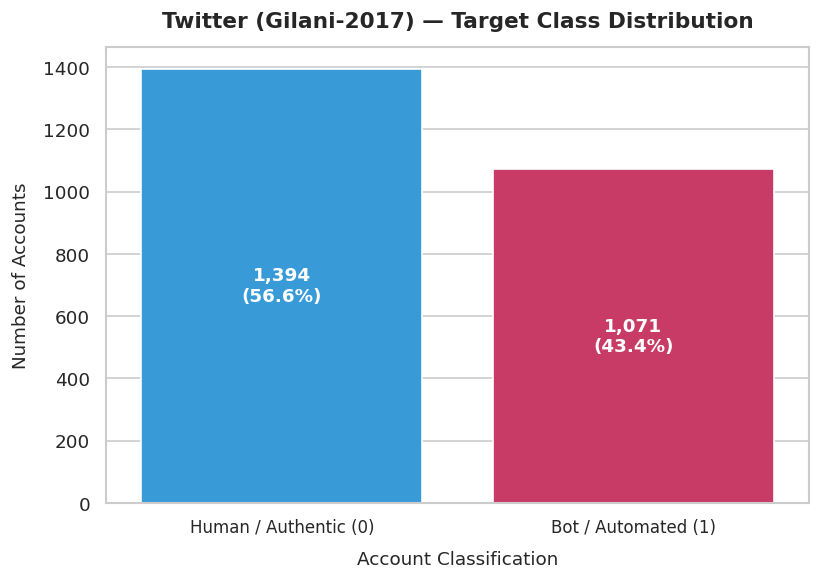

[SAVED] Target distribution graph: /content/drive/MyDrive/Bot_Detection_Project/graphs/twitter/01_target_distribution.png


In [10]:
# ==============================================================================
# GRAPH: TARGET CLASS DISTRIBUTION — 60% HUMAN / 40% BOT
# ==============================================================================

plt.figure(figsize=(7, 5))

palette = ['#1da1f2', '#e0245e']

ax = sns.countplot(
    data=df_feat,
    x='target',
    palette=palette
)

plt.title(
    "Twitter (Gilani-2017) — Target Class Distribution",
    fontsize=13,
    fontweight='bold',
    pad=12
)

plt.xlabel(
    "Account Classification",
    fontsize=11,
    labelpad=8
)

plt.ylabel(
    "Number of Accounts",
    fontsize=11,
    labelpad=8
)

plt.xticks(
    ticks=[0, 1],
    labels=[
        'Human / Authentic (0)',
        'Bot / Automated (1)'
    ],
    fontsize=10
)

# Calculate and display percentages
total_rows = len(df_feat)

for p in ax.patches:
    height = p.get_height()
    percentage = (height / total_rows) * 100

    ax.annotate(
        f"{int(height):,}\n({percentage:.1f}%)",
        (
            p.get_x() + p.get_width() / 2.,
            height / 2
        ),
        ha='center',
        va='center',
        fontsize=11,
        color='white',
        fontweight='bold'
    )

plt.tight_layout()

target_graph_path = os.path.join(
    GRAPH_PATH,
    "01_target_distribution.png"
)

plt.savefig(
    target_graph_path,
    dpi=300,
    bbox_inches='tight'
)

plt.show()
plt.close()

print(f"[SAVED] Target distribution graph: {target_graph_path}")

---
## 9. Numerical Feature Analysis & Descriptive Statistics
Identify continuous profile variables and compute statistical moments (mean, std, median, skewness).

In [11]:
# ==============================================================================
# NUMERICAL FEATURE IDENTIFICATION & DESCRIPTIVE STATISTICS
# ==============================================================================
profile_numerical = [
    'followers_count', 'friends_count', 'statuses_count', 'favourites_count',
    'listed_count', 'followers_friends_ratio', 'favourites_statuses_ratio',
    'statuses_followers_ratio', 'description_length', 'username_length',
    'username_digit_count', 'username_digit_ratio', 'fullname_length', 'fullname_word_count'
]
profile_numerical = [c for c in profile_numerical if c in df_feat.columns]

profile_binary = [
    'verified', 'protected', 'default_profile', 'default_profile_image', 'name_equals_username'
]
profile_binary = [c for c in profile_binary if c in df_feat.columns]

print(f"Continuous Numerical Features ({len(profile_numerical)}):\n{profile_numerical}")
print(f"\nDiscrete Binary Features ({len(profile_binary)}):\n{profile_binary}")

# Descriptive statistics
desc_stats = df_feat[profile_numerical].describe().T
desc_stats['median'] = df_feat[profile_numerical].median()
desc_stats['skewness'] = df_feat[profile_numerical].skew()

print("\n=== Numerical Features Descriptive Statistics ===")
display(desc_stats)

desc_csv_path = os.path.join(RESULT_PATH, "descriptive_statistics.csv")
desc_stats.to_csv(desc_csv_path)
print(f"\n[SAVED] Descriptive statistics table: {desc_csv_path}")

Continuous Numerical Features (14):
['followers_count', 'friends_count', 'statuses_count', 'favourites_count', 'listed_count', 'followers_friends_ratio', 'favourites_statuses_ratio', 'statuses_followers_ratio', 'description_length', 'username_length', 'username_digit_count', 'username_digit_ratio', 'fullname_length', 'fullname_word_count']

Discrete Binary Features (5):
['verified', 'protected', 'default_profile', 'default_profile_image', 'name_equals_username']

=== Numerical Features Descriptive Statistics ===


,count,mean,std,min,25%,50%,75%,max,median,skewness
followers_count,2465.0,1.140064e+06,6.821143e+06,0.000000e+00,1239.000000,93928.000000,231537.000000,1.069380e+08,93928.000000,10.408537
friends_count,2465.0,2.038812e+04,9.579000e+04,0.000000e+00,319.000000,863.000000,2531.000000,2.141379e+06,863.000000,10.829179
statuses_count,2465.0,8.512556e+04,1.599708e+05,1.000000e+00,15424.000000,38528.000000,89591.000000,2.766520e+06,38528.000000,6.709247
favourites_count,2465.0,1.410421e+04,3.924938e+04,0.000000e+00,226.000000,2636.000000,12323.000000,8.861150e+05,2636.000000,9.388934
listed_count,2465.0,2.927768e+03,1.803841e+04,0.000000e+00,16.000000,179.000000,1261.000000,6.065000e+05,179.000000,19.236060
followers_friends_ratio,2465.0,6.892529e+04,1.840986e+06,1.684533e-02,1.353830,12.920635,635.052310,8.340936e+07,12.920635,39.958268
favourites_statuses_ratio,2465.0,9.076923e-01,8.908616e+00,3.614648e-07,0.007295,0.091044,0.435675,2.928889e+02,0.091044,25.725706
statuses_followers_ratio,2465.0,5.402204e+01,1.125181e+03,1.246863e-06,0.087950,0.627213,18.839124,5.552100e+04,0.627213,48.676466
description_length,2465.0,8.463732e+01,5.173658e+01,0.000000e+00,39.000000,87.000000,133.000000,1.810000e+02,87.000000,-0.112244
username_length,2465.0,1.067627e+01,2.809976e+00,2.000000e+00,9.000000,11.000000,13.000000,1.500000e+01,11.000000,-0.328730



[SAVED] Descriptive statistics table: /content/drive/MyDrive/Bot_Detection_Project/results/twitter/descriptive_statistics.csv


---
## 10. Numerical Feature Distribution Graphs
Individual distribution histograms with Kernel Density Estimation (KDE) across classes.

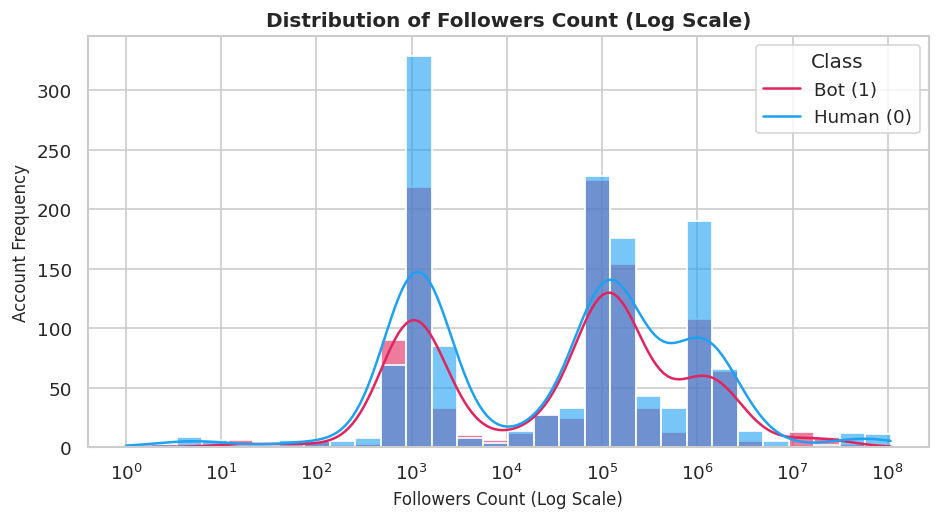

[SAVED] Followers distribution graph: /content/drive/MyDrive/Bot_Detection_Project/graphs/twitter/distribution_followers.png


In [12]:
import numpy as np

# ==============================================================================
# GRAPH: DISTRIBUTION — FOLLOWERS COUNT (LOG SCALE)
# ==============================================================================
plt.figure(figsize=(8, 4.5))
# Add a small constant to followers_count to handle zero values before log transformation
sns.histplot(data=df_feat.assign(followers_count_log=lambda x: x['followers_count'] + 1),
             x='followers_count_log', hue='target', kde=True,
             palette={0: '#1da1f2', 1: '#e0245e'}, log_scale=True, bins=30, alpha=0.6)
plt.title("Distribution of Followers Count (Log Scale)", fontsize=12, fontweight='bold')
plt.xlabel("Followers Count (Log Scale)", fontsize=10)
plt.ylabel("Account Frequency", fontsize=10)
plt.legend(title='Class', labels=['Bot (1)', 'Human (0)'])
plt.tight_layout()

dist_followers_path = os.path.join(GRAPH_PATH, "distribution_followers.png")
plt.savefig(dist_followers_path, dpi=300)
plt.show()
plt.close()
print(f"[SAVED] Followers distribution graph: {dist_followers_path}")

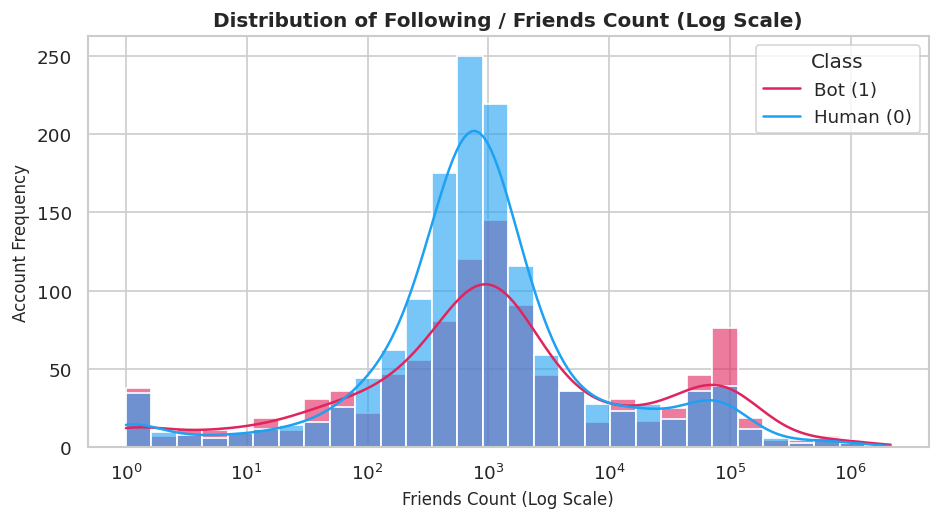

[SAVED] Friends distribution graph: /content/drive/MyDrive/Bot_Detection_Project/graphs/twitter/distribution_friends.png


In [13]:
# ==============================================================================
# GRAPH: DISTRIBUTION — FRIENDS (FOLLOWING) COUNT (LOG SCALE)
# ==============================================================================
plt.figure(figsize=(8, 4.5))
sns.histplot(data=df_feat.assign(friends_count_log=lambda x: x['friends_count'] + 1),
             x='friends_count_log', hue='target', kde=True,
             palette={0: '#1da1f2', 1: '#e0245e'}, log_scale=True, bins=30, alpha=0.6)
plt.title("Distribution of Following / Friends Count (Log Scale)", fontsize=12, fontweight='bold')
plt.xlabel("Friends Count (Log Scale)", fontsize=10)
plt.ylabel("Account Frequency", fontsize=10)
plt.legend(title='Class', labels=['Bot (1)', 'Human (0)'])
plt.tight_layout()

dist_friends_path = os.path.join(GRAPH_PATH, "distribution_friends.png")
plt.savefig(dist_friends_path, dpi=300)
plt.show()
plt.close()
print(f"[SAVED] Friends distribution graph: {dist_friends_path}")

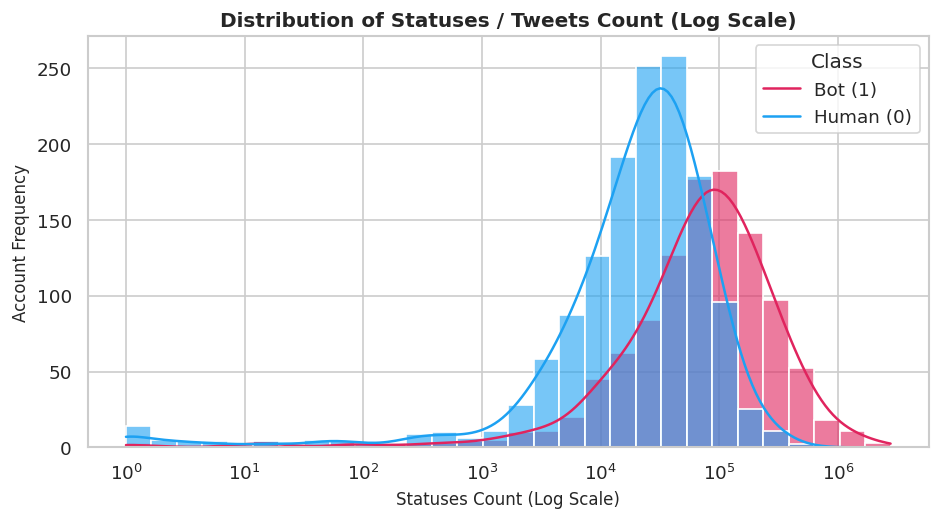

[SAVED] Statuses distribution graph: /content/drive/MyDrive/Bot_Detection_Project/graphs/twitter/distribution_statuses.png


In [14]:
# ==============================================================================
# GRAPH: DISTRIBUTION — STATUSES (TWEETS) COUNT (LOG SCALE)
# ==============================================================================
plt.figure(figsize=(8, 4.5))
sns.histplot(data=df_feat, x='statuses_count', hue='target', kde=True,
             palette={0: '#1da1f2', 1: '#e0245e'}, log_scale=True, bins=30, alpha=0.6)
plt.title("Distribution of Statuses / Tweets Count (Log Scale)", fontsize=12, fontweight='bold')
plt.xlabel("Statuses Count (Log Scale)", fontsize=10)
plt.ylabel("Account Frequency", fontsize=10)
plt.legend(title='Class', labels=['Bot (1)', 'Human (0)'])
plt.tight_layout()

dist_statuses_path = os.path.join(GRAPH_PATH, "distribution_statuses.png")
plt.savefig(dist_statuses_path, dpi=300)
plt.show()
plt.close()
print(f"[SAVED] Statuses distribution graph: {dist_statuses_path}")

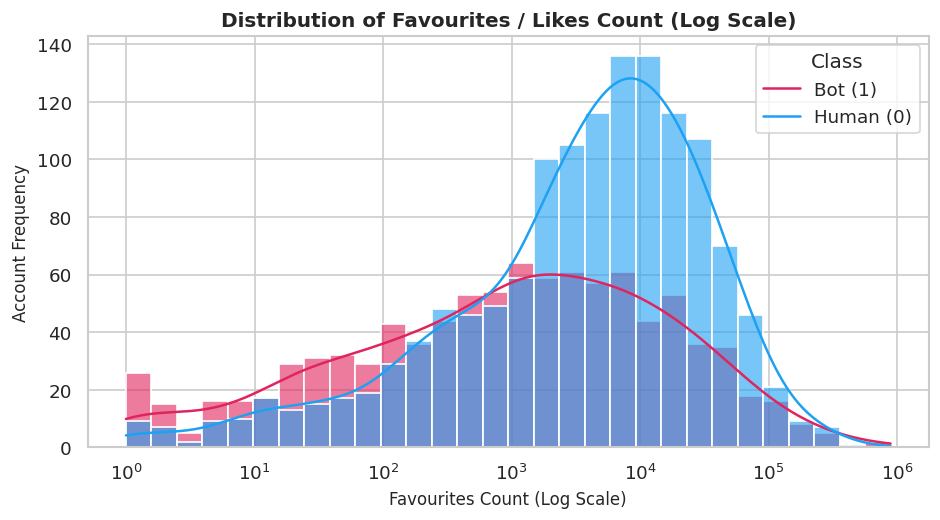

[SAVED] Favourites distribution graph: /content/drive/MyDrive/Bot_Detection_Project/graphs/twitter/distribution_favourites.png


In [15]:
# ==============================================================================
# GRAPH: DISTRIBUTION — FAVOURITES (LIKES) COUNT (LOG SCALE)
# ==============================================================================

# Clean data specifically for this graph
plot_df = df_feat[['favourites_count', 'target']].copy()

# Convert to numeric and handle invalid values
plot_df['favourites_count'] = pd.to_numeric(
    plot_df['favourites_count'],
    errors='coerce'
)

plot_df['favourites_count'] = plot_df['favourites_count'].replace(
    [np.inf, -np.inf],
    np.nan
)

# Remove NaN and zero/negative values
plot_df = plot_df.dropna(
    subset=['favourites_count', 'target']
)

plot_df = plot_df[
    plot_df['favourites_count'] > 0
]

# Plot
plt.figure(figsize=(8, 4.5))

sns.histplot(
    data=plot_df,
    x='favourites_count',
    hue='target',
    kde=True,
    palette={0: '#1da1f2', 1: '#e0245e'},
    log_scale=True,
    bins=30,
    alpha=0.6
)

plt.title(
    "Distribution of Favourites / Likes Count (Log Scale)",
    fontsize=12,
    fontweight='bold'
)

plt.xlabel(
    "Favourites Count (Log Scale)",
    fontsize=10
)

plt.ylabel(
    "Account Frequency",
    fontsize=10
)

plt.legend(
    title='Class',
    labels=['Bot (1)', 'Human (0)']
)

plt.tight_layout()

dist_favs_path = os.path.join(
    GRAPH_PATH,
    "distribution_favourites.png"
)

plt.savefig(
    dist_favs_path,
    dpi=300
)

plt.show()
plt.close()

print(f"[SAVED] Favourites distribution graph: {dist_favs_path}")

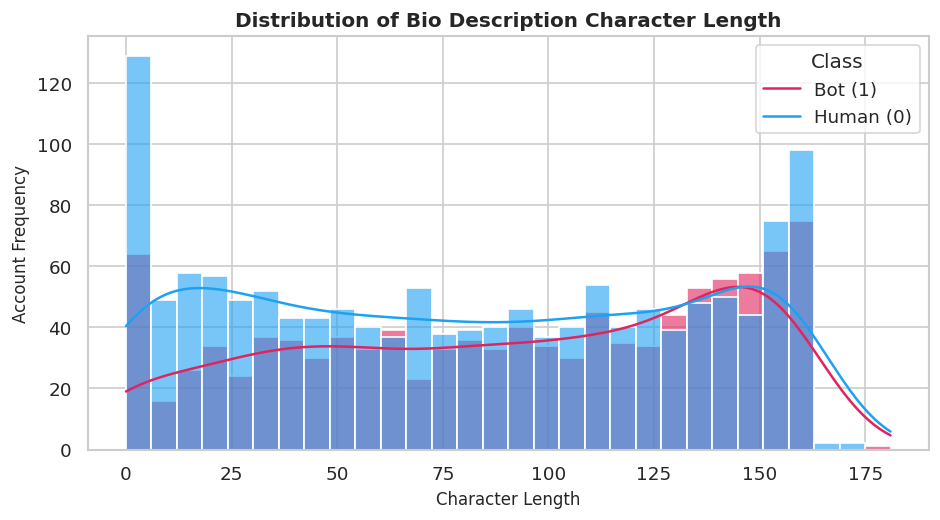

[SAVED] Description length distribution graph: /content/drive/MyDrive/Bot_Detection_Project/graphs/twitter/distribution_description_length.png


In [16]:
# ==============================================================================
# GRAPH: DISTRIBUTION — BIO DESCRIPTION LENGTH
# ==============================================================================
plt.figure(figsize=(8, 4.5))
sns.histplot(data=df_feat, x='description_length', hue='target', kde=True,
             palette={0: '#1da1f2', 1: '#e0245e'}, bins=30, alpha=0.6)
plt.title("Distribution of Bio Description Character Length", fontsize=12, fontweight='bold')
plt.xlabel("Character Length", fontsize=10)
plt.ylabel("Account Frequency", fontsize=10)
plt.legend(title='Class', labels=['Bot (1)', 'Human (0)'])
plt.tight_layout()

dist_desc_path = os.path.join(GRAPH_PATH, "distribution_description_length.png")
plt.savefig(dist_desc_path, dpi=300)
plt.show()
plt.close()
print(f"[SAVED] Description length distribution graph: {dist_desc_path}")

---
## 14. Preprocessing & Zero-Leakage Train/Test Split
Separate features and ground-truth target, execute an 80/20 stratified train/test split, and fit scalers strictly on training records.

In [26]:
# ==============================================================================
# PREPROCESSING & ZERO-LEAKAGE STRATIFIED TRAIN/TEST SPLIT
# ==============================================================================
model_features = profile_numerical + profile_binary

X = df_feat[model_features].copy()
y = df_feat['target'].copy()

print(f"Profile Feature Matrix (X) Shape: {X.shape}")
print(f"Target Vector (y) Shape          : {y.shape}")

# Stratified 80/20 Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED, stratify=y
)

print(f"\nTrain Partition: {X_train.shape[0]} samples (Human={sum(y_train==0)}, Bot={sum(y_train==1)})")
print(f"Test Partition : {X_test.shape[0]} samples (Human={sum(y_test==0)}, Bot={sum(y_test==1)})")

# Strict Zero-Leakage: Fit StandardScaler ONLY on Training Data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# Master performance tracking dictionaries
ml_results = {}
all_model_results = {}
test_probabilities = {}

print("\n[SUCCESS] Scaler fitted strictly on training partition. Zero leakage verified.")

Profile Feature Matrix (X) Shape: (2465, 19)
Target Vector (y) Shape          : (2465,)

Train Partition: 1972 samples (Human=1115, Bot=857)
Test Partition : 493 samples (Human=279, Bot=214)

[SUCCESS] Scaler fitted strictly on training partition. Zero leakage verified.


---
## 15. Twitter Profile Model 1: Logistic Regression
Train an L2-regularized linear classifier on standardized profile features.

In [27]:
# ==============================================================================
# TWITTER PROFILE MODEL 1: LOGISTIC REGRESSION
# ==============================================================================
lr_model = LogisticRegression(max_iter=1000, random_state=SEED)
lr_model.fit(X_train_scaled, y_train)

# Inference on test set
y_pred_lr = lr_model.predict(X_test_scaled)
y_prob_lr = lr_model.predict_proba(X_test_scaled)[:, 1]
test_probabilities['Logistic Regression (Profile)'] = y_prob_lr

# Compute evaluation metrics
acc_lr  = accuracy_score(y_test, y_pred_lr)
prec_lr = precision_score(y_test, y_pred_lr, zero_division=0)
rec_lr  = recall_score(y_test, y_pred_lr, zero_division=0)
f1_lr   = f1_score(y_test, y_pred_lr, zero_division=0)

ml_results['Logistic Regression'] = {'Accuracy': acc_lr, 'Precision': prec_lr, 'Recall': rec_lr, 'F1 Score': f1_lr}
all_model_results['Logistic Regression'] = {'Category': 'Profile ML', 'Accuracy': acc_lr, 'Precision': prec_lr, 'Recall': rec_lr, 'F1 Score': f1_lr}

print("=== Logistic Regression Performance ===")
print(f"  Accuracy  : {acc_lr:.4f}")
print(f"  Precision : {prec_lr:.4f}")
print(f"  Recall    : {rec_lr:.4f}")
print(f"  F1 Score  : {f1_lr:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr, target_names=['Human (0)', 'Bot (1)']))

# Save model artifact
lr_model_path = os.path.join(MODEL_PATH, "logistic_regression.pkl")
joblib.dump(lr_model, lr_model_path)
print(f"[SAVED] Model artifact: {lr_model_path}")

=== Logistic Regression Performance ===
  Accuracy  : 0.7221
  Precision : 0.7391
  Recall    : 0.5561
  F1 Score  : 0.6347

Classification Report:
              precision    recall  f1-score   support

   Human (0)       0.71      0.85      0.78       279
     Bot (1)       0.74      0.56      0.63       214

    accuracy                           0.72       493
   macro avg       0.73      0.70      0.71       493
weighted avg       0.72      0.72      0.71       493

[SAVED] Model artifact: /content/drive/MyDrive/Bot_Detection_Project/models/twitter/logistic_regression.pkl


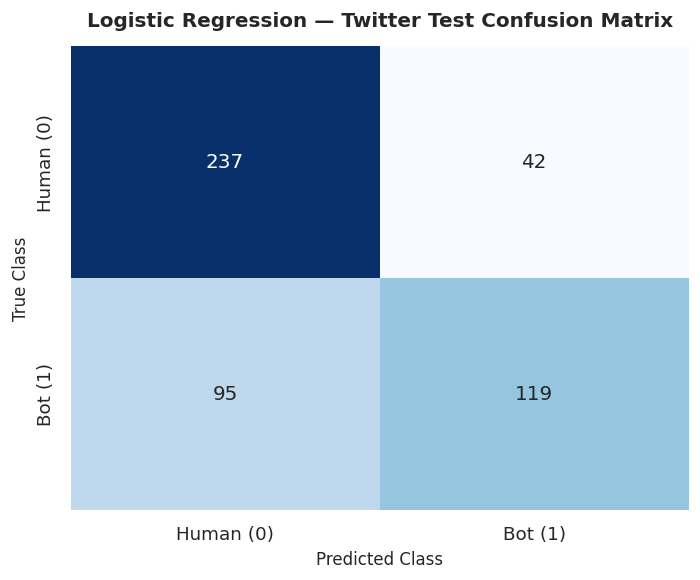

[SAVED] Logistic Regression confusion matrix: /content/drive/MyDrive/Bot_Detection_Project/graphs/twitter/logistic_confusion_matrix.png


In [28]:
# ==============================================================================
# GRAPH: CONFUSION MATRIX — LOGISTIC REGRESSION
# ==============================================================================
cm_lr = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Human (0)', 'Bot (1)'], yticklabels=['Human (0)', 'Bot (1)'])
plt.title("Logistic Regression — Twitter Test Confusion Matrix", fontsize=12, fontweight='bold', pad=12)
plt.xlabel("Predicted Class", fontsize=10)
plt.ylabel("True Class", fontsize=10)
plt.tight_layout()

cm_lr_path = os.path.join(GRAPH_PATH, "logistic_confusion_matrix.png")
plt.savefig(cm_lr_path, dpi=300)
plt.show()
plt.close()
print(f"[SAVED] Logistic Regression confusion matrix: {cm_lr_path}")

---
## 16. Twitter Profile Model 2: Random Forest & Feature Importance
Train an ensemble of decision trees and calculate Gini split feature importances.

In [29]:
# ==============================================================================
# TWITTER PROFILE MODEL 2: RANDOM FOREST
# ==============================================================================
rf_model = RandomForestClassifier(n_estimators=100, random_state=SEED, n_jobs=-1)
rf_model.fit(X_train, y_train)

# Inference on test set
y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]
test_probabilities['Random Forest (Profile)'] = y_prob_rf

# Compute evaluation metrics
acc_rf  = accuracy_score(y_test, y_pred_rf)
prec_rf = precision_score(y_test, y_pred_rf, zero_division=0)
rec_rf  = recall_score(y_test, y_pred_rf, zero_division=0)
f1_rf   = f1_score(y_test, y_pred_rf, zero_division=0)

ml_results['Random Forest'] = {'Accuracy': acc_rf, 'Precision': prec_rf, 'Recall': rec_rf, 'F1 Score': f1_rf}
all_model_results['Random Forest'] = {'Category': 'Profile ML', 'Accuracy': acc_rf, 'Precision': prec_rf, 'Recall': rec_rf, 'F1 Score': f1_rf}

print("=== Random Forest Performance ===")
print(f"  Accuracy  : {acc_rf:.4f}")
print(f"  Precision : {prec_rf:.4f}")
print(f"  Recall    : {rec_rf:.4f}")
print(f"  F1 Score  : {f1_rf:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf, target_names=['Human (0)', 'Bot (1)']))

# Save model artifact
rf_model_path = os.path.join(MODEL_PATH, "random_forest.pkl")
joblib.dump(rf_model, rf_model_path)
print(f"[SAVED] Model artifact: {rf_model_path}")

# Feature importance computation
rf_importance_df = pd.DataFrame({
    'Feature': model_features,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False).reset_index(drop=True)

rf_imp_csv_path = os.path.join(RESULT_PATH, "random_forest_feature_importance.csv")
rf_importance_df.to_csv(rf_imp_csv_path, index=False)
print(f"[SAVED] Feature importance table: {rf_imp_csv_path}")

=== Random Forest Performance ===
  Accuracy  : 0.7586
  Precision : 0.7654
  Recall    : 0.6402
  F1 Score  : 0.6972

Classification Report:
              precision    recall  f1-score   support

   Human (0)       0.75      0.85      0.80       279
     Bot (1)       0.77      0.64      0.70       214

    accuracy                           0.76       493
   macro avg       0.76      0.74      0.75       493
weighted avg       0.76      0.76      0.75       493

[SAVED] Model artifact: /content/drive/MyDrive/Bot_Detection_Project/models/twitter/random_forest.pkl
[SAVED] Feature importance table: /content/drive/MyDrive/Bot_Detection_Project/results/twitter/random_forest_feature_importance.csv


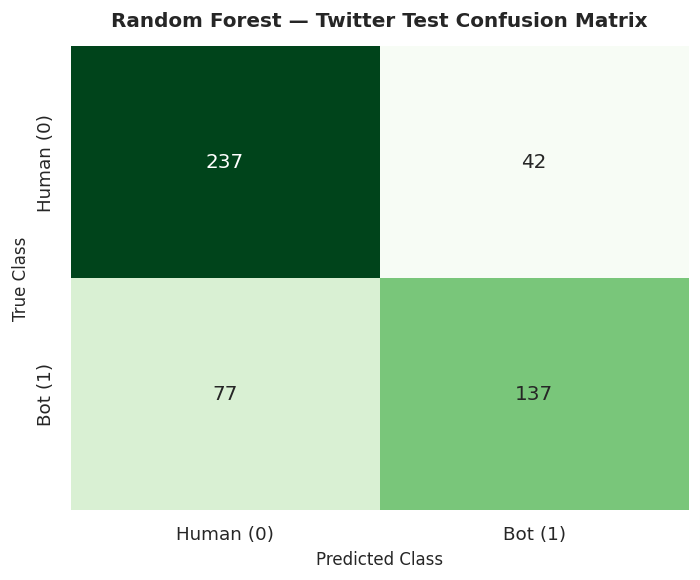

[SAVED] Random Forest confusion matrix: /content/drive/MyDrive/Bot_Detection_Project/graphs/twitter/random_forest_confusion_matrix.png


In [30]:
# ==============================================================================
# GRAPH: CONFUSION MATRIX — RANDOM FOREST
# ==============================================================================
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens', cbar=False,
            xticklabels=['Human (0)', 'Bot (1)'], yticklabels=['Human (0)', 'Bot (1)'])
plt.title("Random Forest — Twitter Test Confusion Matrix", fontsize=12, fontweight='bold', pad=12)
plt.xlabel("Predicted Class", fontsize=10)
plt.ylabel("True Class", fontsize=10)
plt.tight_layout()

cm_rf_path = os.path.join(GRAPH_PATH, "random_forest_confusion_matrix.png")
plt.savefig(cm_rf_path, dpi=300)
plt.show()
plt.close()
print(f"[SAVED] Random Forest confusion matrix: {cm_rf_path}")

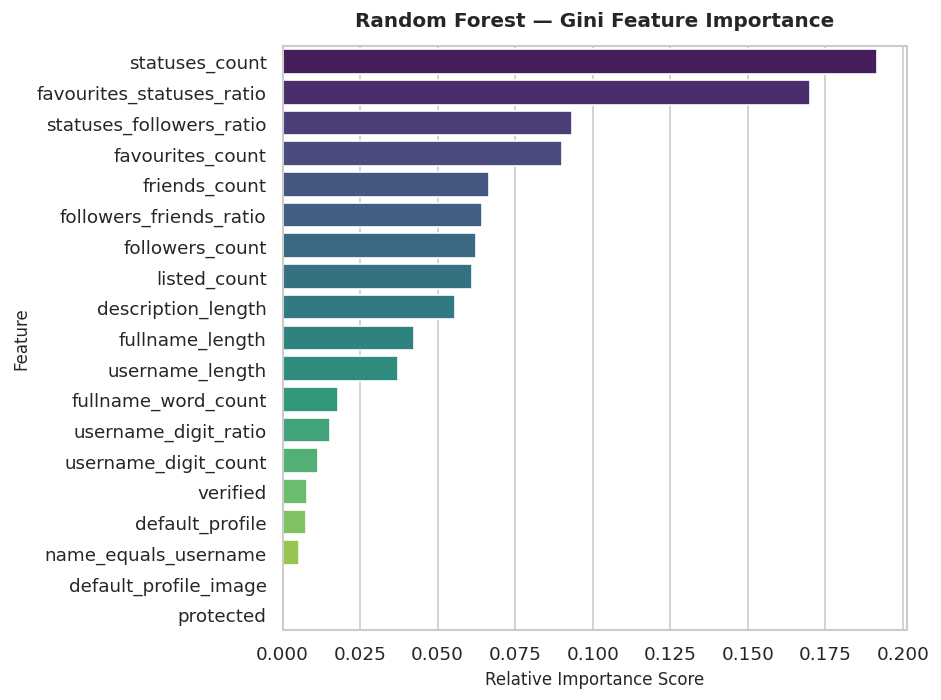

[SAVED] Random Forest feature importance graph: /content/drive/MyDrive/Bot_Detection_Project/graphs/twitter/random_forest_feature_importance.png


In [31]:
# ==============================================================================
# GRAPH: FEATURE IMPORTANCE — RANDOM FOREST
# ==============================================================================
plt.figure(figsize=(8, 6))
sns.barplot(data=rf_importance_df, x='Importance', y='Feature', palette='viridis')
plt.title("Random Forest — Gini Feature Importance", fontsize=12, fontweight='bold', pad=12)
plt.xlabel("Relative Importance Score", fontsize=10)
plt.ylabel("Feature", fontsize=10)
plt.tight_layout()

rf_imp_graph_path = os.path.join(GRAPH_PATH, "random_forest_feature_importance.png")
plt.savefig(rf_imp_graph_path, dpi=300)
plt.show()
plt.close()
print(f"[SAVED] Random Forest feature importance graph: {rf_imp_graph_path}")

---
## 17. Twitter Profile Model 3: XGBoost Classifier
Train an extreme gradient-boosted decision tree ensemble on tabular profile indicators.

In [32]:
# ==============================================================================
# TWITTER PROFILE MODEL 3: XGBOOST CLASSIFIER
# ==============================================================================
xgb_model = xgb.XGBClassifier(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=4,
    random_state=SEED,
    eval_metric='logloss'
)
xgb_model.fit(X_train, y_train)

# Inference on test set
y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]
test_probabilities['XGBoost (Profile)'] = y_prob_xgb

# Compute evaluation metrics
acc_xgb  = accuracy_score(y_test, y_pred_xgb)
prec_xgb = precision_score(y_test, y_pred_xgb, zero_division=0)
rec_xgb  = recall_score(y_test, y_pred_xgb, zero_division=0)
f1_xgb   = f1_score(y_test, y_pred_xgb, zero_division=0)

ml_results['XGBoost'] = {'Accuracy': acc_xgb, 'Precision': prec_xgb, 'Recall': rec_xgb, 'F1 Score': f1_xgb}
all_model_results['XGBoost'] = {'Category': 'Profile ML', 'Accuracy': acc_xgb, 'Precision': prec_xgb, 'Recall': rec_xgb, 'F1 Score': f1_xgb}

print("=== XGBoost Performance ===")
print(f"  Accuracy  : {acc_xgb:.4f}")
print(f"  Precision : {prec_xgb:.4f}")
print(f"  Recall    : {rec_xgb:.4f}")
print(f"  F1 Score  : {f1_xgb:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb, target_names=['Human (0)', 'Bot (1)']))

# Save model artifact
xgb_model_path = os.path.join(MODEL_PATH, "xgboost.pkl")
joblib.dump(xgb_model, xgb_model_path)
print(f"[SAVED] Model artifact: {xgb_model_path}")

# Feature importance computation
xgb_importance_df = pd.DataFrame({
    'Feature': model_features,
    'Importance': xgb_model.feature_importances_
}).sort_values(by='Importance', ascending=False).reset_index(drop=True)

xgb_imp_csv_path = os.path.join(RESULT_PATH, "xgboost_feature_importance.csv")
xgb_importance_df.to_csv(xgb_imp_csv_path, index=False)
print(f"[SAVED] XGBoost feature importance table: {xgb_imp_csv_path}")

=== XGBoost Performance ===
  Accuracy  : 0.7525
  Precision : 0.7706
  Recall    : 0.6121
  F1 Score  : 0.6823

Classification Report:
              precision    recall  f1-score   support

   Human (0)       0.74      0.86      0.80       279
     Bot (1)       0.77      0.61      0.68       214

    accuracy                           0.75       493
   macro avg       0.76      0.74      0.74       493
weighted avg       0.75      0.75      0.75       493

[SAVED] Model artifact: /content/drive/MyDrive/Bot_Detection_Project/models/twitter/xgboost.pkl
[SAVED] XGBoost feature importance table: /content/drive/MyDrive/Bot_Detection_Project/results/twitter/xgboost_feature_importance.csv


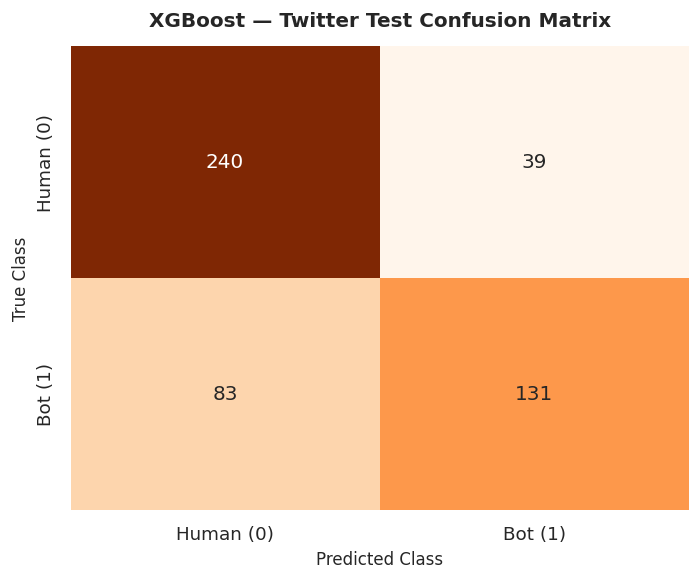

[SAVED] XGBoost confusion matrix: /content/drive/MyDrive/Bot_Detection_Project/graphs/twitter/xgboost_confusion_matrix.png


In [33]:
# ==============================================================================
# GRAPH: CONFUSION MATRIX — XGBOOST
# ==============================================================================
cm_xgb = confusion_matrix(y_test, y_pred_xgb)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Oranges', cbar=False,
            xticklabels=['Human (0)', 'Bot (1)'], yticklabels=['Human (0)', 'Bot (1)'])
plt.title("XGBoost — Twitter Test Confusion Matrix", fontsize=12, fontweight='bold', pad=12)
plt.xlabel("Predicted Class", fontsize=10)
plt.ylabel("True Class", fontsize=10)
plt.tight_layout()

cm_xgb_path = os.path.join(GRAPH_PATH, "xgboost_confusion_matrix.png")
plt.savefig(cm_xgb_path, dpi=300)
plt.show()
plt.close()
print(f"[SAVED] XGBoost confusion matrix: {cm_xgb_path}")

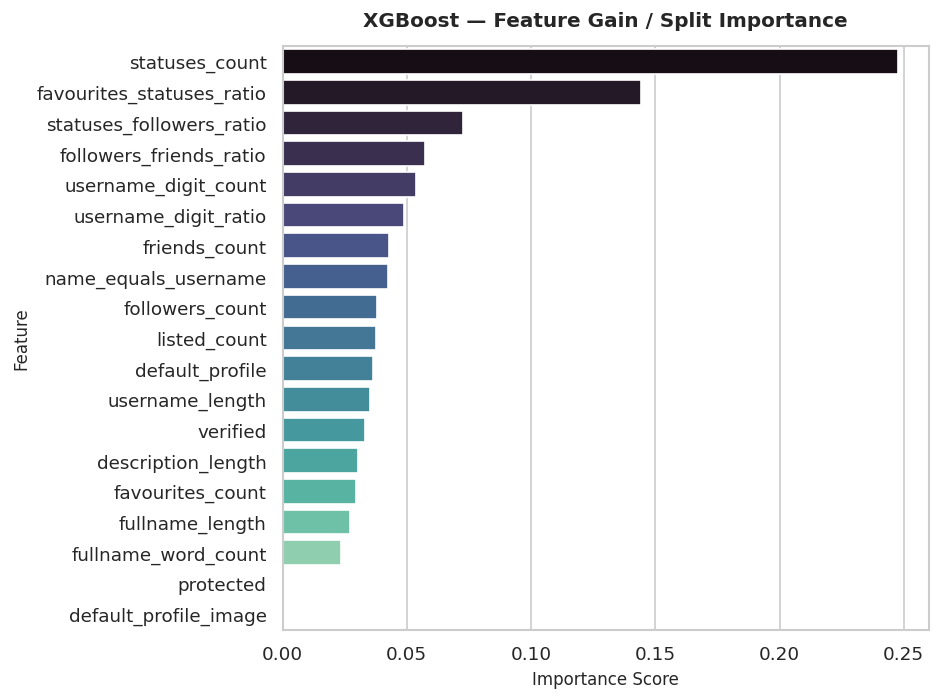

[SAVED] XGBoost feature importance graph: /content/drive/MyDrive/Bot_Detection_Project/graphs/twitter/xgboost_feature_importance.png


In [34]:
# ==============================================================================
# GRAPH: FEATURE IMPORTANCE — XGBOOST
# ==============================================================================
plt.figure(figsize=(8, 6))
sns.barplot(data=xgb_importance_df, x='Importance', y='Feature', palette='mako')
plt.title("XGBoost — Feature Gain / Split Importance", fontsize=12, fontweight='bold', pad=12)
plt.xlabel("Importance Score", fontsize=10)
plt.ylabel("Feature", fontsize=10)
plt.tight_layout()

xgb_imp_graph_path = os.path.join(GRAPH_PATH, "xgboost_feature_importance.png")
plt.savefig(xgb_imp_graph_path, dpi=300)
plt.show()
plt.close()
print(f"[SAVED] XGBoost feature importance graph: {xgb_imp_graph_path}")

In [35]:
# ==============================================================================
# TWITTER PROFILE ML COMPARISON TABLE
# ==============================================================================
ml_records = []
for m_name, m_metrics in ml_results.items():
    ml_records.append({
        'Model': m_name,
        'Accuracy': round(m_metrics['Accuracy'], 4),
        'Precision': round(m_metrics['Precision'], 4),
        'Recall': round(m_metrics['Recall'], 4),
        'F1 Score': round(m_metrics['F1 Score'], 4)
    })

ml_df = pd.DataFrame(ml_records).sort_values(by='F1 Score', ascending=False).reset_index(drop=True)
print("=== Twitter Profile ML Models Leaderboard ===")
display(ml_df)

ml_csv_path = os.path.join(RESULT_PATH, "twitter_ml_comparison.csv")
ml_df.to_csv(ml_csv_path, index=False)
print(f"\n[SAVED] Twitter Profile ML comparison table: {ml_csv_path}")

=== Twitter Profile ML Models Leaderboard ===


,Model,Accuracy,Precision,Recall,F1 Score
0,Random Forest,0.7586,0.7654,0.6402,0.6972
1,XGBoost,0.7525,0.7706,0.6121,0.6823
2,Logistic Regression,0.7221,0.7391,0.5561,0.6347



[SAVED] Twitter Profile ML comparison table: /content/drive/MyDrive/Bot_Detection_Project/results/twitter/twitter_ml_comparison.csv
